<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week15/Day5/MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Analyze and Present A/B Test Results

X company recently introduced a new bidding type, “average bidding”, as an alternative to its exisiting bidding
type, called “maximum bidding”. One of our clients, X.com, has decided to test this new feature
and wants to conduct an A/B test to understand if average bidding brings more conversions than maximum
bidding.

In this A/B test, X.com randomly splits its audience into two equally sized groups, e.g. the test
and the control group. A X company ad campaign with “maximum bidding” is served to “control group” and
another campaign with “average bidding” is served to the “test group”.

The A/B test has run for 1 month and X.com now expects you to analyze and present the results
of this A/B test.



##### You should answer the following questions in this notebook

1. How would you define the hypothesis of this A/B test?
2. Can we conclude statistically significant results?
3. Which statistical test did you use, and why?
4. Based on your answer to Question 2, what would be your recommendation to client?


##### Hints:

1. The customer journey for this campaign is:
    1. User sees an ad (Impression)
    2. User clicks on the website link on the ad (Website Click)
    3. User makes a search on the website (Search)
    4. User views details of a product (View Content)
    5. User adds the product to the cart (Add to Cart)
    6. User purchases the product (Purchase)
2. Use visualizations to compare test and control group metrics, such as Website Click Through Rate, Cost per Action, and Conversion Rates in addition to Purchase numbers.
3. If you see trends, anomalies or other patterns, discuss these in your notebool.
4. You can make assumptions if needed.


---

### Completed version

This notebook keeps the original exercise structure and completes every `#TODO`,
including data preparation, KNN imputation, feature engineering, assumption checks,
the final hypothesis test, interpretation, and client recommendation.


## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import skewtest
from scipy.stats import median_test
from scipy.stats import shapiro
import pylab
from sklearn.neighbors import LocalOutlierFactor
from scipy.stats import levene
from statsmodels.stats.proportion import proportions_ztest
from sklearn.impute import KNNImputer

pd.set_option("display.max_columns",None);
pd.set_option("display.max_rows",None);

## 2. Functions

In [2]:
def read_data():
    """
    Loads the control and test campaign CSV files extracted from the project ZIP.

    Control group = Maximum Bidding (existing strategy)
    Test group    = Average Bidding (new strategy)

    The control dataset contains missing numerical values on one day.
    We keep that row because the project specifically asks us to handle
    missing values later with KNNImputer.
    """
    control = pd.read_csv("/content/ab_test_data/control_group.csv", sep=";")
    test = pd.read_csv("/content/ab_test_data/test_group.csv", sep=";")
    return control, test


def get_catvar(df):
    """Return the categorical columns and a dataframe containing them."""
    cat_col = [
        col for col in df.columns
        if (df[col].dtype == "object") | (df[col].dtype == "bool")
    ]
    kat_df = pd.DataFrame(df[cat_col], index=df.index)
    return df, kat_df, cat_col


def get_numvar(cat_col, df):
    """Return the numerical columns and a dataframe containing them."""
    num_col = [c for c in df.columns if c not in cat_col]
    num_df = pd.DataFrame(df[num_col], index=df.index)
    return df, num_df, num_col


def fill_NaNValue(num_control):
    """
    Fill missing numerical values using KNN imputation.

    KNNImputer looks for rows with similar numerical patterns and estimates
    missing values using their nearest neighbours.
    """
    cols = num_control.columns
    imputer = KNNImputer(n_neighbors=8)
    num_control = imputer.fit_transform(num_control)
    num_control = pd.DataFrame(num_control, columns=cols)
    return num_control


def convert_datatype(control):
    """Convert count-based columns to integers after imputation."""
    control = control.astype({
        "# of Impressions": "int64",
        "Reach": "int64",
        "# of Website Clicks": "int64",
        "# of Searches": "int64",
        "# of View Content": "int64",
        "# of Add to Cart": "int64",
        "# of Purchase": "int64"
    })
    return control


def outliers(control, test):
    """Original helper supplied in the exercise for LOF-based outlier inspection."""
    clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
    clf.fit_predict(test.iloc[:, 2:])[0:10]

    test_scores = clf.negative_outlier_factor_
    print("Test Score:", np.sort(test_scores)[0:20])

    threshold = np.sort(test_scores)[4]
    print("Threshold score:", threshold)

    return test_scores


def feature_engineering(control, test):
    """
    Create campaign-performance features.

    Website Click Through Rate (CTR)
        Website clicks / impressions * 100

    Number of Action
        Sum of impressions, clicks, searches, views, add-to-cart and purchases.

    Cost per Action
        Campaign spend / number of actions.

    Conversion Rate
        The notebook's supplied definition:
        Number of Action / Website Clicks * 100
    """
    control = control.copy()
    test = test.copy()

    control["Website Click Through Rate"] = (
        control["# of Website Clicks"] / control["# of Impressions"] * 100
    )
    test["Website Click Through Rate"] = (
        test["# of Website Clicks"] / test["# of Impressions"] * 100
    )

    control["Number of Action"] = (
        control["# of Impressions"]
        + control["# of Website Clicks"]
        + control["# of Searches"]
        + control["# of View Content"]
        + control["# of Add to Cart"]
        + control["# of Purchase"]
    )
    test["Number of Action"] = (
        test["# of Impressions"]
        + test["# of Website Clicks"]
        + test["# of Searches"]
        + test["# of View Content"]
        + test["# of Add to Cart"]
        + test["# of Purchase"]
    )

    control["Cost per Action"] = control["Spend [USD]"] / control["Number of Action"]
    test["Cost per Action"] = test["Spend [USD]"] / test["Number of Action"]

    control["Conversion Rate"] = (
        control["Number of Action"] / control["# of Website Clicks"] * 100
    )
    test["Conversion Rate"] = (
        test["Number of Action"] / test["# of Website Clicks"] * 100
    )

    return control, test


def data_prepare_for_visualization(control, test):
    """Combine the main metrics from both experiment groups for visualization."""
    control_nop = pd.DataFrame(control["# of Purchase"])
    test_nop = pd.DataFrame(test["# of Purchase"])

    control_wctr = pd.DataFrame(control["Website Click Through Rate"])
    test_wctr = pd.DataFrame(test["Website Click Through Rate"])

    control_cpa = pd.DataFrame(control["Cost per Action"])
    test_cpa = pd.DataFrame(test["Cost per Action"])

    control_cr = pd.DataFrame(control["Conversion Rate"])
    test_cr = pd.DataFrame(test["Conversion Rate"])

    Group_A = pd.concat(
        [control_nop, control_wctr, control_cpa, control_cr], axis=1
    )
    Group_A["Group"] = "A (MaximumBidding)"

    Group_B = pd.concat(
        [test_nop, test_wctr, test_cpa, test_cr], axis=1
    )
    Group_B["Group"] = "B (AverageBidding)"

    AB = pd.concat([Group_A, Group_B], ignore_index=True)
    return AB, control_nop, test_nop


def data_prepare_for_hypothesis_testing(control_nop, test_nop):
    """Put purchase observations from both groups side by side."""
    df_AB = pd.concat(
        [
            control_nop.reset_index(drop=True),
            test_nop.reset_index(drop=True)
        ],
        axis=1
    )
    df_AB.columns = ["A", "B"]
    return df_AB


def num_boxplot(fig, axarr, dimension, cols, hue):
    """Helper used by show_boxplot()."""
    cols = cols.copy()

    for i in dimension:
        for j in dimension:
            if not cols:
                return

            c = cols.pop(0)
            sns.boxplot(y=c, x=hue, data=AB, ax=axarr[i][j])


def show_boxplot(nrows, ncols, dimension, cols, figsize):
    """Display boxplots comparing the experiment groups."""
    fig, axarr = plt.subplots(nrows, ncols, figsize=figsize)
    num_boxplot(fig, axarr, dimension, cols, "Group")
    plt.tight_layout()
    plt.show()


def checkReject(p_value, alpha=0.05):
    """Interpret a p-value using alpha = 0.05."""
    if p_value < alpha:
        print(f"{p_value} < alpha(0.05) so >>> H0 REJECTED")
    else:
        print(f"{p_value} >= alpha(0.05) so >>> H0 CAN'T BE REJECTED")

## 3. Data Preparation

In [3]:
# Import the dataset supplied with the mini-project.
# In Colab, upload:
# "AB Test & Hypothesis Testing for E-commerce.zip"

from google.colab import files
import zipfile
import os
import glob

uploaded = files.upload()
uploaded_file = list(uploaded.keys())[0]

extract_dir = "/content/ab_test_raw"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(uploaded_file, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

# Locate the two CSV files inside the ZIP, even if they are nested in folders.
control_source = glob.glob(
    os.path.join(extract_dir, "**", "control_group.csv"),
    recursive=True
)[0]

test_source = glob.glob(
    os.path.join(extract_dir, "**", "test_group.csv"),
    recursive=True
)[0]

# Copy them to simple, predictable paths used by read_data().
os.makedirs("/content/ab_test_data", exist_ok=True)

import shutil
shutil.copy(control_source, "/content/ab_test_data/control_group.csv")
shutil.copy(test_source, "/content/ab_test_data/test_group.csv")

print("Dataset extracted successfully.")
print("Control:", control_source)
print("Test:   ", test_source)

Saving AB Test & Hypothesis Testing for E-commerce.zip to AB Test & Hypothesis Testing for E-commerce.zip
Dataset extracted successfully.
Control: /content/ab_test_raw/AB Test & Hypothesis Testing for E-commerce/AB Test & Hypothesis Testing for E-commerce/control_group.csv
Test:    /content/ab_test_raw/AB Test & Hypothesis Testing for E-commerce/AB Test & Hypothesis Testing for E-commerce/test_group.csv


In [4]:
control, test = read_data()

In [5]:
# Inspect the control group: Maximum Bidding
print("CONTROL GROUP — Maximum Bidding")
print("Shape:", control.shape)
display(control.head())

print("\nData types:")
print(control.dtypes)

CONTROL GROUP — Maximum Bidding
Shape: (30, 10)


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Data types:
Campaign Name           object
Date                    object
Spend [USD]              int64
# of Impressions       float64
Reach                  float64
# of Website Clicks    float64
# of Searches          float64
# of View Content      float64
# of Add to Cart       float64
# of Purchase          float64
dtype: object


In [6]:
# Inspect the test group: Average Bidding
print("TEST GROUP — Average Bidding")
print("Shape:", test.shape)
display(test.head())

print("\nData types:")
print(test.dtypes)

TEST GROUP — Average Bidding
Shape: (30, 10)


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768



Data types:
Campaign Name          object
Date                   object
Spend [USD]             int64
# of Impressions        int64
Reach                   int64
# of Website Clicks     int64
# of Searches           int64
# of View Content       int64
# of Add to Cart        int64
# of Purchase           int64
dtype: object


In [7]:
# Check missing values in the control group
print("Null values in control:")
display(control.isnull().sum())

print("\nTotal missing values:", control.isnull().sum().sum())

Null values in control:


,0
Campaign Name,0
Date,0
Spend [USD],0
# of Impressions,1
Reach,1
# of Website Clicks,1
# of Searches,1
# of View Content,1
# of Add to Cart,1
# of Purchase,1



Total missing values: 7


In [8]:
# Separate categorical and numerical variables in the control dataframe.

# 1) Get categorical columns
control, kat_control, cat_cols = get_catvar(control)

# 2) Get numerical columns
control, num_control, num_cols = get_numvar(cat_cols, control)

print("Categorical columns:")
print(cat_cols)

print("\nNumerical columns:")
print(num_cols)

print("\nCategorical dataframe:")
display(kat_control.head())

print("\nNumerical dataframe:")
display(num_control.head())

Categorical columns:
['Campaign Name', 'Date']

Numerical columns:
['Spend [USD]', '# of Impressions', 'Reach', '# of Website Clicks', '# of Searches', '# of View Content', '# of Add to Cart', '# of Purchase']

Categorical dataframe:


,Campaign Name,Date
0,Control Campaign,1.08.2019
1,Control Campaign,2.08.2019
2,Control Campaign,3.08.2019
3,Control Campaign,4.08.2019
4,Control Campaign,5.08.2019



Numerical dataframe:


,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Fill missing numerical values in the control group using KNNImputer.
# n_neighbors=8 is defined inside the helper function.

num_control_imputed = fill_NaNValue(num_control)

print("Null values after KNN imputation:")
display(num_control_imputed.isnull().sum())

Null values after KNN imputation:


,0
Spend [USD],0
# of Impressions,0
Reach,0
# of Website Clicks,0
# of Searches,0
# of View Content,0
# of Add to Cart,0
# of Purchase,0


In [10]:
# Combine the categorical variables with the imputed numerical variables.

control = pd.concat(
    [
        kat_control.reset_index(drop=True),
        num_control_imputed.reset_index(drop=True)
    ],
    axis=1
)

# Reorder the columns to match the original dataset.
control = control[
    [
        "Campaign Name", "Date", "Spend [USD]", "# of Impressions",
        "Reach", "# of Website Clicks", "# of Searches",
        "# of View Content", "# of Add to Cart", "# of Purchase"
    ]
]

print("Combined control dataframe:")
display(control.head())

print("\nRemaining null values:", control.isnull().sum().sum())

Combined control dataframe:


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280.0,82702.0,56930.000,7016.000,2290.00,2159.00,1819.000,618.000
1,Control Campaign,2.08.2019,1757.0,121040.0,102513.000,8110.000,2033.00,1841.00,1219.000,511.000
2,Control Campaign,3.08.2019,2343.0,131711.0,110862.000,6508.000,1737.00,1549.00,1134.000,372.000
3,Control Campaign,4.08.2019,1940.0,72878.0,61235.000,3065.000,1042.00,982.00,1183.000,340.000
4,Control Campaign,5.08.2019,1835.0,100341.5,82046.625,5527.375,2023.25,1821.75,1231.875,514.375



Remaining null values: 0


In [11]:
# Let's do a data type conversion.

control = convert_datatype(control)

print(control.shape)
print(test.shape)

(30, 10)
(30, 10)


In [12]:
# Check your dataframes

print(control.info())
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Campaign Name        30 non-null     object 
 1   Date                 30 non-null     object 
 2   Spend [USD]          30 non-null     float64
 3   # of Impressions     30 non-null     int64  
 4   Reach                30 non-null     int64  
 5   # of Website Clicks  30 non-null     int64  
 6   # of Searches        30 non-null     int64  
 7   # of View Content    30 non-null     int64  
 8   # of Add to Cart     30 non-null     int64  
 9   # of Purchase        30 non-null     int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 2.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Campaign Name        30 

## 4. Preparing Data for Hypothesis Testing (A/B Test)



In [13]:
# Apply feature engineering to both groups.
#
# The function creates four additional campaign metrics:
# 1. Website Click Through Rate (CTR)
# 2. Number of Action
# 3. Cost per Action
# 4. Conversion Rate
#
# These features make it easier to compare campaign performance beyond
# simply looking at the raw number of purchases.

control, test = feature_engineering(control, test)

# Prepare one combined dataframe for visual comparison.
AB, control_nop, test_nop = data_prepare_for_visualization(control, test)

print("Engineered control data:")
display(control.head(3))

print("\nEngineered test data:")
display(test.head(3))

print("\nCombined visualization dataframe:")
display(AB.head(3))

Engineered control data:


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase,Website Click Through Rate,Number of Action,Cost per Action,Conversion Rate
0,Control Campaign,1.08.2019,2280.0,82702,56930,7016,2290,2159,1819,618,8.483471,96604,0.023602,1376.909920
1,Control Campaign,2.08.2019,1757.0,121040,102513,8110,2033,1841,1219,511,6.700264,134754,0.013039,1661.578298
2,Control Campaign,3.08.2019,2343.0,131711,110862,6508,1737,1549,1134,372,4.941121,143011,0.016383,2197.464659



Engineered test data:


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase,Website Click Through Rate,Number of Action,Cost per Action,Conversion Rate
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255,7.681416,46752,0.064339,1538.907176
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677,4.623755,110839,0.022934,2380.051535
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578,11.222123,84933,0.027845,1077.146481



Combined visualization dataframe:


,# of Purchase,Website Click Through Rate,Cost per Action,Conversion Rate,Group
0,618,8.483471,0.023602,1376.909920,A (MaximumBidding)
1,511,6.700264,0.013039,1661.578298,A (MaximumBidding)
2,372,4.941121,0.016383,2197.464659,A (MaximumBidding)


Let's look at the numbers A and B.

In [14]:
AB["Group"].value_counts()

,count
Group,
A (MaximumBidding),30
B (AverageBidding),30


### 4.1. Website Click Through Rate (CTR)
Review :
- It is a rate that shows how often the users who saw the ad CLICK the ad.
- Number of Ad Clicks / Number of Ad Displays
- Example: 5 clicks, CTR at 100 impressions = 5%

- ##### Use visualizations to compare test and control group metrics, such as Website Click Through Rate, Cost per Action, and Conversion Rates in addition to Purchase numbers.

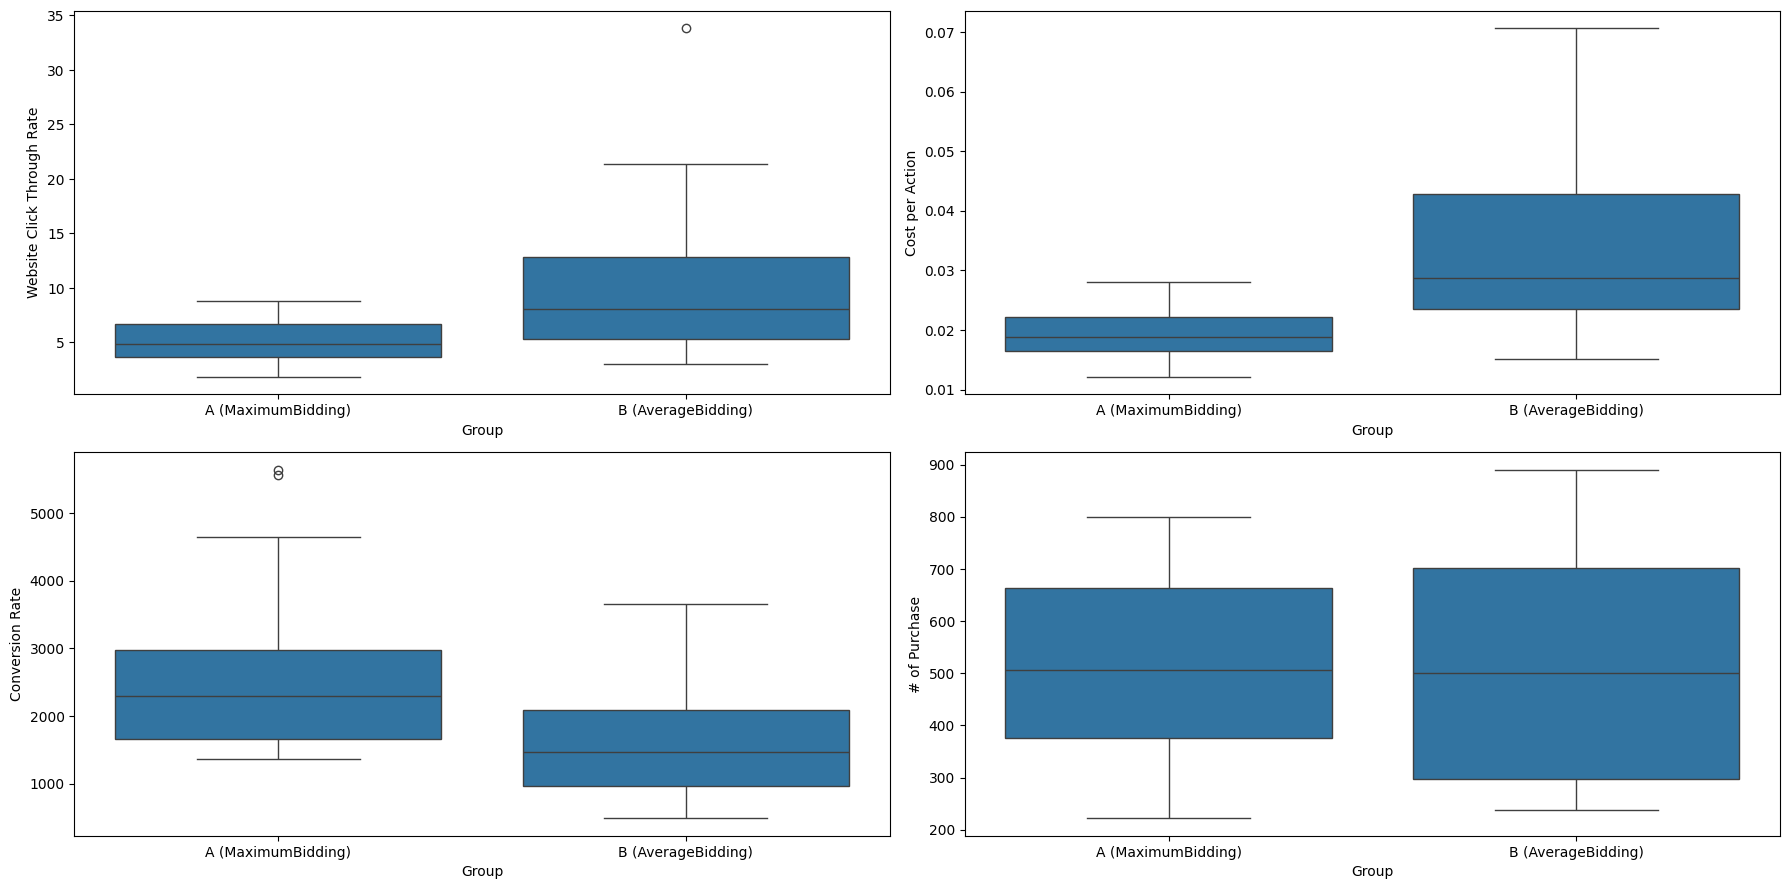

In [15]:
cols = ["Website Click Through Rate","Cost per Action","Conversion Rate","# of Purchase"]
show_boxplot(2,2,[0,1],cols,(18,9))

In [16]:
# Create the dataframe used for hypothesis testing.
# A = Maximum Bidding (Control)
# B = Average Bidding (Test)

df_AB = data_prepare_for_hypothesis_testing(control_nop, test_nop)

print("First 3 rows of the A/B hypothesis-testing dataframe:")
display(df_AB.head(3))

print("\nGroup means:")
print(df_AB.mean())

First 3 rows of the A/B hypothesis-testing dataframe:


,A,B
0,618,255
1,511,677
2,372,578



Group means:
A    522.500000
B    521.233333
dtype: float64


## 5. Two Independent Sample T-Test
### 5.1. Assumption Check
#### 5.1.1. Normality Assumption (shapiro test)

 * **H0**: Normal distribution assumption is provided.
 * **H1**: ... not provided.

In [17]:
# Apply the Shapiro-Wilk normality test to Group A (Maximum Bidding).

shapiro_A = shapiro(df_AB["A"])

print("Group A — Maximum Bidding")
print(f"Shapiro statistic: {shapiro_A.statistic:.4f}")
print(f"P-value: {shapiro_A.pvalue:.4f}")

Group A — Maximum Bidding
Shapiro statistic: 0.9428
P-value: 0.1082


In [18]:
# Extract and round Group A's p-value, then interpret it.

p_value_A = round(shapiro_A.pvalue, 3)

print("Rounded p-value:", p_value_A)
checkReject(p_value_A)

Rounded p-value: 0.108
0.108 >= alpha(0.05) so >>> H0 CAN'T BE REJECTED


### Does the H0 hypothesis get rejected? Why?

**No.** For Group A, the Shapiro-Wilk p-value is approximately **0.108**, which is greater than α = 0.05.

Therefore, we **fail to reject H0**. There is not enough statistical evidence to say that the purchase distribution for the Maximum Bidding group is non-normal.

In [19]:
# Apply the Shapiro-Wilk normality test to Group B (Average Bidding).

shapiro_B = shapiro(df_AB["B"])

print("Group B — Average Bidding")
print(f"Shapiro statistic: {shapiro_B.statistic:.4f}")
print(f"P-value: {shapiro_B.pvalue:.4f}")

Group B — Average Bidding
Shapiro statistic: 0.9182
P-value: 0.0241


In [20]:
# Extract and round Group B's p-value, then interpret it.

p_value_B = round(shapiro_B.pvalue, 3)

print("Rounded p-value:", p_value_B)
checkReject(p_value_B)

Rounded p-value: 0.024
0.024 < alpha(0.05) so >>> H0 REJECTED


### Does the H0 hypothesis get rejected? Why?

**Yes.** For Group B, the Shapiro-Wilk p-value is approximately **0.024**, which is below α = 0.05.

Therefore, we **reject H0**. The purchase distribution for the Average Bidding group does **not** satisfy the normality assumption.

Because at least one of the two groups violates normality, a non-parametric two-independent-sample test is more appropriate than the standard independent-samples t-test.

### 5.1.2. Variance Homogeneity Assumption
 * **H0** : Variances are homogeneous.
 * **H1** : Variances are not homogeneous.

We want to assess if A and B have equal variances, which is a common assumption for various statistical tests :

In [21]:
# Levene's test checks whether the two groups have equal variances.

levene_result = levene(df_AB["A"], df_AB["B"])

print(f"Levene statistic: {levene_result.statistic:.4f}")
print(f"P-value: {levene_result.pvalue:.4f}")

Levene statistic: 1.6899
P-value: 0.1988


In [22]:
# Extract and round the Levene-test p-value.

levene_p = round(levene_result.pvalue, 3)

print("Rounded p-value:", levene_p)
checkReject(levene_p)

Rounded p-value: 0.199
0.199 >= alpha(0.05) so >>> H0 CAN'T BE REJECTED


### Are the variances homogeneous?

**Yes, based on Levene's test we do not have evidence that the variances are different.**

The p-value is approximately **0.199**, which is greater than α = 0.05. Therefore, we **fail to reject H0** and the homogeneity-of-variance assumption is considered satisfied.

However, the normality assumption was violated for Group B, so we will still use a non-parametric test for the final A/B comparison.

### 5.1.3. Nonparametric Independent Two-Sample T-Test

- Since the normality of the distribution of the data set in which Average Bidding (Test Group) was measured was rejected, the NonParametric Independent Two-Sample T Test was applied for the Hypothesis Test.

**Hypothesis:**

 * **H0** : When it comes to Maximum Bidding and Average Bidding, there is no statistically significant difference between the purchasing amounts of the two groups. ($\mu_1 = \mu_2$)

 * **H1** : ... there is a difference ($\mu_1 \neq \mu_2$)

In [23]:
# Final non-parametric hypothesis test.
# A = Maximum Bidding
# B = Average Bidding

stats.mannwhitneyu(
    df_AB["A"],
    df_AB["B"],
    alternative="two-sided"
)

MannwhitneyuResult(statistic=np.float64(455.0), pvalue=np.float64(0.9469515266277105))

In [24]:
# Mann-Whitney U test: non-parametric comparison of two independent groups.

mann_whitney = stats.mannwhitneyu(
    df_AB["A"],
    df_AB["B"],
    alternative="two-sided"
)

mann_p = round(mann_whitney.pvalue, 3)

print(f"Mann-Whitney U statistic: {mann_whitney.statistic:.4f}")
print(f"Rounded p-value: {mann_p}")

checkReject(mann_p)

Mann-Whitney U statistic: 455.0000
Rounded p-value: 0.947
0.947 >= alpha(0.05) so >>> H0 CAN'T BE REJECTED


### Should H0 be rejected? Why? What can we conclude?

**No. H0 should not be rejected.**

The Mann-Whitney U test gives a p-value of approximately **0.947**, which is much greater than α = 0.05.

This means the experiment does **not** provide statistically significant evidence that the purchase results differ between Maximum Bidding and Average Bidding.

The average number of purchases is also almost identical:

- **Maximum Bidding:** about **522.5 purchases**
- **Average Bidding:** about **521.2 purchases**

So, based on purchases, Average Bidding did not demonstrate a statistically significant improvement over Maximum Bidding during this one-month experiment.

## 6. Conclusion and Evaluation

### 1. How would you define the hypothesis of this A/B test?

The business question is whether the new **Average Bidding** strategy generates a different — and ideally higher — level of purchases than the existing **Maximum Bidding** strategy.

For the statistical test used in this notebook:

- **H0 (Null Hypothesis):** There is no statistically significant difference in purchases between Maximum Bidding and Average Bidding.
- **H1 (Alternative Hypothesis):** There is a statistically significant difference in purchases between the two bidding strategies.

In notation:

**H0: μA = μB**  
**H1: μA ≠ μB**

where A represents Maximum Bidding and B represents Average Bidding.

---

### 2. Can we conclude statistically significant results?

**No.**

The Mann-Whitney U test produced a p-value of approximately **0.947**.

Since:

**0.947 > 0.05**

we fail to reject the null hypothesis.

The observed difference in purchases is not statistically significant.

---

### 3. Which statistical test did you use, and why?

I used the **Mann-Whitney U test**, a non-parametric test for comparing two independent groups.

Before choosing the test, I checked the assumptions:

- Group A passed the Shapiro-Wilk normality test (**p ≈ 0.108**).
- Group B failed the Shapiro-Wilk normality test (**p ≈ 0.024**).
- Levene's test did not indicate unequal variances (**p ≈ 0.199**).

Because the Average Bidding group violated the normality assumption, I chose the Mann-Whitney U test rather than relying on a standard independent-samples t-test.

---

### 4. Based on Question 2, what would be your recommendation to the client?

I would **not recommend replacing Maximum Bidding with Average Bidding solely on the basis of purchase performance from this experiment**.

The average purchases were almost the same:

- Maximum Bidding: **~522.5**
- Average Bidding: **~521.2**

and the difference was not statistically significant.

A practical recommendation would be to:

1. Keep the current Maximum Bidding strategy as the default for now.
2. Continue testing Average Bidding with a larger sample or over a longer period.
3. Evaluate additional business metrics such as CTR, Cost per Action, Conversion Rate and total spend before making a final rollout decision.

### Final business conclusion

The test does **not** show evidence that Average Bidding improves purchases compared with Maximum Bidding. The new strategy may still have value on other efficiency metrics, but the current one-month experiment is not enough to justify a switch based on purchases alone.